## 1. Imports

In [ ]:
import numpy as np
import os
import scipy.io as sio
from scipy.signal import butter, filtfilt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

2025-11-10 00:25:03.680206: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 00:25:05.709013: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 00:25:07.938197: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## 2. Data Loading and Concatenation

In [ ]:
import numpy as np
import scipy.io as sio
import os

def load_and_concatenate(folder_path):
    all_data = []

    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith('.mat'):
            file_path = os.path.join(folder_path, filename)
            mat_data = sio.loadmat(file_path)
            key_name = filename.split('.')[0]
            eeg_signal = mat_data.get(key_name)

            if eeg_signal is not None:
                print(f"Shape of EEG signal in {filename}: {eeg_signal.shape}")
                all_data.append(eeg_signal)
            else:
                print(f"Warning: Key '{key_name}' not found in {filename}. Skipping.")

    # Vertically concatenate all recordings (stack by time)
    if all_data:
        concatenated_data = np.vstack(all_data)
        print(f"\nFinal concatenated EEG shape for {os.path.basename(folder_path)}: {concatenated_data.shape}")
        return concatenated_data
    else:
        print(f"No .mat files found in {folder_path}")
        return None


# Example usage:
folder_ad_part1 = '/home/user/Downloads/apr_proj/NAIRITA_eeg/ADHD_part1'
folder_control_part1 = '/home/user/Downloads/apr_proj/NAIRITA_eeg/Control_part1'

eeg_ad_part1 = load_and_concatenate(folder_ad_part1)
eeg_control_part1 = load_and_concatenate(folder_control_part1)

# Repeat for part2 for testing data (if you have the corresponding folders)
folder_ad_part2 = '/home/user/Downloads/apr_proj/NAIRITA_eeg/ADHD_part2'
folder_control_part2 = '/home/user/Downloads/apr_proj/NAIRITA_eeg/Control_part2'

eeg_ad_part2 = load_and_concatenate(folder_ad_part2)
eeg_control_part2 = load_and_concatenate(folder_control_part2)

Shape of EEG signal in v10p.mat: (14304, 19)
Shape of EEG signal in v12p.mat: (17604, 19)
Shape of EEG signal in v14p.mat: (17562, 19)
Shape of EEG signal in v15p.mat: (43252, 19)
Shape of EEG signal in v173.mat: (24241, 19)
Shape of EEG signal in v18p.mat: (25003, 19)
Shape of EEG signal in v19p.mat: (23063, 19)
Shape of EEG signal in v1p.mat: (12258, 19)
Shape of EEG signal in v20p.mat: (35328, 19)
Shape of EEG signal in v21p.mat: (16574, 19)
Shape of EEG signal in v22p.mat: (12100, 19)
Shape of EEG signal in v24p.mat: (16385, 19)
Shape of EEG signal in v25p.mat: (9894, 19)
Shape of EEG signal in v27p.mat: (28880, 19)
Shape of EEG signal in v28p.mat: (27612, 19)
Shape of EEG signal in v29p.mat: (24193, 19)
Shape of EEG signal in v30p.mat: (21663, 19)
Shape of EEG signal in v31p.mat: (11679, 19)
Shape of EEG signal in v32p.mat: (18049, 19)
Shape of EEG signal in v33p.mat: (29217, 19)
Shape of EEG signal in v34p.mat: (19555, 19)
Shape of EEG signal in v35p.mat: (15305, 19)
Shape of EEG

## 3. EEG Preprocessing (Filtering and Normalization)

In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt

# Bandpass filter parameters
Fs = 250  # Sampling frequency
low_cutoff = 1  # Low cutoff frequency for bandpass filter (Hz)
high_cutoff = 40  # High cutoff frequency for bandpass filter (Hz)

# Design Butterworth bandpass filter
b, a = butter(4, [low_cutoff, high_cutoff], fs=Fs, btype='band')


def preprocess_eeg(eeg_data, seg_size=1000):
    clean_data = []

    # --- Ensure correct shape ---
    eeg_data = np.squeeze(eeg_data)  # Remove singleton dimensions

    # If the data is 2D (samples × channels), make it 3D with one sample
    if eeg_data.ndim == 2:
        eeg_data = np.expand_dims(eeg_data, axis=0)

    print(f"Preprocessing EEG data with shape: {eeg_data.shape}")

    for i in range(eeg_data.shape[0]):  # Iterate through each EEG sample
        segment = eeg_data[i]

        # Skip malformed data
        if segment.ndim != 2:
            print(f"⚠️ Skipping malformed sample {i} with shape {segment.shape}")
            continue

        filtered_segment = np.zeros_like(segment)

        for ch in range(segment.shape[1]):  # Loop through 19 channels
            sig = segment[:, ch]
            sig_filt = filtfilt(b, a, sig)
            sig_norm = 2 * ((sig_filt - np.min(sig_filt)) / (np.max(sig_filt) - np.min(sig_filt))) - 1
            filtered_segment[:, ch] = sig_norm

        clean_data.append(filtered_segment)

    return np.array(clean_data)
# Apply preprocessing on the loaded data
eeg_ad_part1_cleaned = preprocess_eeg(eeg_ad_part1)
eeg_control_part1_cleaned = preprocess_eeg(eeg_control_part1)
eeg_ad_part2_cleaned = preprocess_eeg(eeg_ad_part2)
eeg_control_part2_cleaned = preprocess_eeg(eeg_control_part2)

Preprocessing EEG data with shape: (1, 620284, 19)
Preprocessing EEG data with shape: (1, 441556, 19)
Preprocessing EEG data with shape: (1, 424689, 19)
Preprocessing EEG data with shape: (1, 517758, 19)


## 4. Data Segmentation

In [ ]:
def segment_eeg(data, window_size=1000, step_size=1000):
    """
    Segments EEG data into overlapping/non-overlapping windows.
    Input shape: (n_samples, n_channels)
    Output shape: (n_segments, window_size, n_channels)
    """
    segments = []
    n_samples = data.shape[0]
    for start in range(0, n_samples - window_size + 1, step_size):
        end = start + window_size
        segment = data[start:end, :]
        segments.append(segment)
    return np.array(segments)

## 5. Prepare Data for Segmentation

In [ ]:
eeg_ad_part1_cleaned.shape, eeg_control_part1_cleaned.shape
# Remove the first dimension if it exists
eeg_ad_part1_cleaned = np.squeeze(eeg_ad_part1_cleaned)
eeg_control_part1_cleaned = np.squeeze(eeg_control_part1_cleaned)

eeg_ad_part2_cleaned = np.squeeze(eeg_ad_part2_cleaned)
eeg_control_part2_cleaned = np.squeeze(eeg_control_part2_cleaned)

print(eeg_ad_part1_cleaned.shape, eeg_control_part1_cleaned.shape)

(620284, 19) (441556, 19)


## 6. Combine and Segment Data

In [ ]:
# Segment each dataset
segments_ad1 = segment_eeg(eeg_ad_part1_cleaned, window_size=1000)
segments_control1 = segment_eeg(eeg_control_part1_cleaned, window_size=1000)

segments_ad2 = segment_eeg(eeg_ad_part2_cleaned, window_size=1000)
segments_control2 = segment_eeg(eeg_control_part2_cleaned, window_size=1000)

# Combine all
X = np.concatenate([segments_ad1, segments_ad2,segments_control1, segments_control2], axis=0)
y = np.concatenate([
    np.zeros(segments_ad1.shape[0]),  # ADHD = 0
    np.zeros(segments_ad2.shape[0]),
    np.ones(segments_control1.shape[0]),  # Control = 1
    np.ones(segments_control2.shape[0])
])

print(f"Shape of X: {X.shape}")  # (num_segments, 1000, 19)
print(f"Shape of y: {y.shape}")

Shape of X: (2002, 1000, 19)
Shape of y: (2002,)


## 7. Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 8. Segment Normalization

In [ ]:
def normalize_segment(segment):
    segment = (segment - np.mean(segment, axis=0)) / (np.std(segment, axis=0) + 1e-8)
    return np.clip(segment, -5, 5)  # optional to avoid outliers

X_train = np.array([normalize_segment(x) for x in X_train])
X_test = np.array([normalize_segment(x) for x in X_test])

## 9. Data Augmentation (Gaussian Noise)

In [ ]:
import numpy as np

def add_gaussian_noise(eeg_data, noise_std=0.02):
    """
    Add Gaussian noise to EEG data to improve robustness.
    noise_std controls the noise strength (relative to signal amplitude).
    """
    noisy_data = eeg_data + np.random.normal(0, noise_std, eeg_data.shape)
    return noisy_data

# Add Gaussian noise to training data only
X_train = add_gaussian_noise(X_train, noise_std=0.02)
X_test = add_gaussian_noise(X_test, noise_std=0.02)

## 10. CNN Model Definition and Training

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import regularizers

def create_cnn_model(input_shape):
    model = models.Sequential([
        layers.InputLayer(input_shape=input_shape),

        layers.Conv1D(16, 10, strides=2, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.4),

        layers.Conv1D(32, 5, strides=2, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.4),

        layers.Flatten(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')
    ])
    return model

# Create CNN model
input_shape = (X_train.shape[1], X_train.shape[2])  # (time, channels)
model = create_cnn_model(input_shape)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=2)#,callbacks=[callback])

# Evaluate the model

# Evaluate the model
train_loss, train_acc = model.evaluate(X_train, y_train)
print(f"train Accuracy: {train_acc * 100:.2f}%")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Epoch 1/20
44/44 - 2s - loss: 1.3732 - accuracy: 0.5432 - val_loss: 0.7225 - val_accuracy: 0.5341 - 2s/epoch - 47ms/step
Epoch 2/20
44/44 - 1s - loss: 0.7530 - accuracy: 0.6031 - val_loss: 0.7039 - val_accuracy: 0.5607 - 765ms/epoch - 17ms/step
Epoch 3/20
44/44 - 1s - loss: 0.7071 - accuracy: 0.6017 - val_loss: 0.6868 - val_accuracy: 0.5890 - 771ms/epoch - 18ms/step
Epoch 4/20
44/44 - 1s - loss: 0.6661 - accuracy: 0.6174 - val_loss: 0.6603 - val_accuracy: 0.6156 - 758ms/epoch - 17ms/step
Epoch 5/20
44/44 - 1s - loss: 0.6272 - accuracy: 0.6852 - val_loss: 0.6432 - val_accuracy: 0.6656 - 780ms/epoch - 18ms/step
Epoch 6/20
44/44 - 1s - loss: 0.5955 - accuracy: 0.6916 - val_loss: 0.6236 - val_accuracy: 0.6872 - 774ms/epoch - 18ms/step
Epoch 7/20
44/44 - 1s - loss: 0.5811 - accuracy: 0.7138 - val_loss: 0.6118 - val_accuracy: 0.6889 - 781ms/epoch - 18ms/step
Epoch 8/20
44/44 - 1s - loss: 0.5407 - accuracy: 0.7395 - val_loss: 0.6097 - val_accuracy: 0.6988 - 778ms/epoch - 18ms/step
Epoch 9/20


## 11. CNN Model Evaluation and Visualization

44/44 [==============================] - 0s 6ms/step - loss: 0.1382 - accuracy: 0.9722
Train Accuracy: 97.22%
19/19 [==============================] - 0s 6ms/step - loss: 0.5085 - accuracy: 0.7887
Test Accuracy: 78.87%


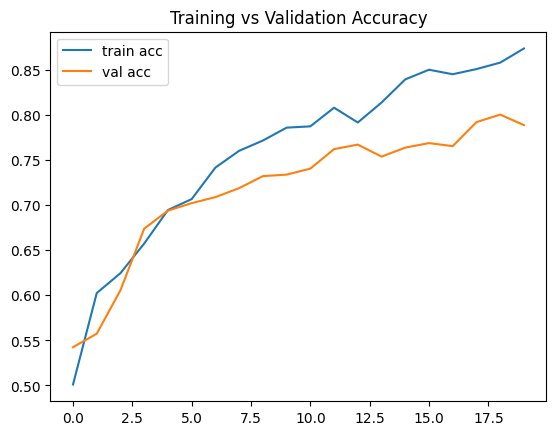

In [ ]:
import matplotlib.pyplot as plt
# Evaluate the model
train_loss, train_acc = model.evaluate(X_train, y_train)
print(f"Train Accuracy: {train_acc * 100:.2f}%")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

## 12. Confusion Matrix for CNN Model

13/13 [==============================] - 0s 5ms/step
Test Accuracy: 77.81%


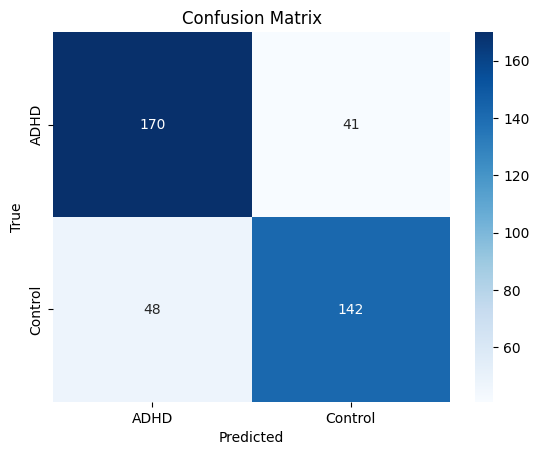

In [ ]:
# Predict on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get the class with the highest probability

# Calculate accuracy
accuracy = np.mean(y_pred_classes == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['ADHD', 'Control'], yticklabels=['ADHD', 'Control'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## 13. Cross-Validation Data Preparation Functions (Not used in subsequent training)

In [ ]:
# Example structure (modify according to your dataset organization)
subjects_data = {
    'ADHD_1': eeg_ad_part1_cleaned,
    'ADHD_2': eeg_ad_part2_cleaned,
    'CTRL_1': eeg_control_part1_cleaned,
    'CTRL_2': eeg_control_part2_cleaned,
    # Add all subjects...
}

subject_labels = {
    'ADHD_1': 0,
    'ADHD_2': 0,
    'CTRL_1': 1,
    'CTRL_2': 1,
}
from itertools import combinations
import numpy as np

subject_names = list(subjects_data.keys())
splits = list(combinations(subject_names, 2))  # Leave-2-out

def segment_and_normalize(eeg_signal, window_size=1000):
    segments = segment_eeg(eeg_signal, window_size)
    segments = (segments - np.mean(segments, axis=0)) / (np.std(segments, axis=0) + 1e-8)
    return np.clip(segments, -5, 5)

def prepare_data(train_subjects, test_subjects):
    X_train, y_train, X_test, y_test = [], [], [], []

    for s in train_subjects:
        seg = segment_and_normalize(subjects_data[s])
        lbl = np.full(seg.shape[0], subject_labels[s])
        X_train.append(seg)
        y_train.append(lbl)

    for s in test_subjects:
        seg = segment_and_normalize(subjects_data[s])
        lbl = np.full(seg.shape[0], subject_labels[s])
        X_test.append(seg)
        y_test.append(lbl)

    X_train = np.concatenate(X_train, axis=0)
    y_train = np.concatenate(y_train, axis=0)
    X_test = np.concatenate(X_test, axis=0)
    y_test = np.concatenate(y_test, axis=0)

    return X_train, y_train, X_test, y_test


## 14. ResNet1D Model Definition

In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def residual_block(x, filters, kernel_size=3, stride=1):
    """
    1D Residual block with identity or projection shortcut.
    """
    shortcut = x

    # First convolution
    x = layers.Conv1D(filters, kernel_size, strides=stride, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second convolution
    x = layers.Conv1D(filters, kernel_size, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # Projection shortcut (if dimensions differ)
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding='same',
                                 kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add skip connection
    x = layers.add([x, shortcut])
    x = layers.ReLU()(x)
    return x


def build_resnet1d(input_shape, num_classes=2):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(64, 7, strides=2, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(3, strides=2, padding='same')(x)

    # Residual blocks (depth can be tuned)
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


# =============================
# Build and Train the Model
# =============================
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_resnet1d(input_shape=input_shape, num_classes=2)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 1000, 19)]           0         []                            
                                                                                                  
 conv1d_48 (Conv1D)          (None, 500, 64)              8576      ['input_5[0][0]']             
                                                                                                  
 batch_normalization_48 (Ba  (None, 500, 64)              256       ['conv1d_48[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 re_lu_40 (ReLU)             (None, 500, 64)              0         ['batch_normalization_48

## 15. ResNet1D Model Training and Evaluation

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(5e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    verbose=2,
                    callbacks=[callback])

# Evaluate performance
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"✅ Train Accuracy: {train_acc * 100:.2f}%")
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")

Epoch 1/30
44/44 - 9s - loss: 1.1344 - accuracy: 0.5396 - val_loss: 0.8668 - val_accuracy: 0.5474 - 9s/epoch - 210ms/step
Epoch 2/30
44/44 - 4s - loss: 0.8903 - accuracy: 0.6331 - val_loss: 0.8302 - val_accuracy: 0.6356 - 4s/epoch - 97ms/step
Epoch 3/30
44/44 - 4s - loss: 0.8399 - accuracy: 0.6867 - val_loss: 0.7522 - val_accuracy: 0.7221 - 4s/epoch - 97ms/step
Epoch 4/30
44/44 - 4s - loss: 0.7148 - accuracy: 0.7509 - val_loss: 0.7035 - val_accuracy: 0.7271 - 4s/epoch - 97ms/step
Epoch 5/30
44/44 - 4s - loss: 0.6216 - accuracy: 0.7951 - val_loss: 0.7843 - val_accuracy: 0.6755 - 4s/epoch - 97ms/step
Epoch 6/30
44/44 - 4s - loss: 0.5516 - accuracy: 0.8387 - val_loss: 0.7173 - val_accuracy: 0.7288 - 4s/epoch - 96ms/step
Epoch 7/30
44/44 - 4s - loss: 0.4511 - accuracy: 0.8958 - val_loss: 0.8502 - val_accuracy: 0.7371 - 4s/epoch - 96ms/step
Epoch 8/30
44/44 - 4s - loss: 0.3628 - accuracy: 0.9336 - val_loss: 0.6220 - val_accuracy: 0.7937 - 4s/epoch - 96ms/step
Epoch 9/30
44/44 - 4s - loss: 0

## 16. SE-ResNet1D Model Definition and Training (Attempt 1)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# ========== Squeeze-and-Excitation Block ==========
def se_block(input_tensor, reduction=16):
    """
    Squeeze-and-Excitation block for 1D data.
    It adaptively recalibrates channel-wise feature responses.
    """
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling1D()(input_tensor)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Multiply()([input_tensor, tf.expand_dims(se, axis=1)])
    return se


# ========== Residual Block with SE Attention ==========
def residual_block_se(x, filters, kernel_size=3, stride=1):
    """
    Residual block with Squeeze-and-Excitation (SE) attention.
    """
    shortcut = x

    # --- First convolution ---
    x = layers.Conv1D(filters, kernel_size, strides=stride, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # --- Second convolution ---
    x = layers.Conv1D(filters, kernel_size, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # --- Squeeze-and-Excitation attention ---
    x = se_block(x)

    # --- Projection shortcut (if needed) ---
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding='same',
                                 kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # --- Skip connection + activation ---
    x = layers.add([x, shortcut])
    x = layers.ReLU()(x)
    return x


# ========== SE-ResNet1D Architecture ==========
def build_se_resnet1d(input_shape, num_classes=2):
    inputs = layers.Input(shape=input_shape)

    # Initial convolution
    x = layers.Conv1D(64, 7, strides=2, padding='same',
                      kernel_regularizer=regularizers.l2(1e-3))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(3, strides=2, padding='same')(x)

    # Residual + SE blocks
    x = residual_block_se(x, 64)
    x = residual_block_se(x, 64)
    x = residual_block_se(x, 128, stride=2)
    x = residual_block_se(x, 128)
    x = residual_block_se(x, 256, stride=2)
    x = residual_block_se(x, 256)

    # Global pooling and classifier
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.75)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="SE-ResNet1D")
    return model


# ========== Build and Train ==========
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_se_resnet1d(input_shape=input_shape, num_classes=2)

model.compile(optimizer=tf.keras.optimizers.Adam(5e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

history = model.fit(X_train, y_train,
                    epochs=40,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    verbose=2,
                    callbacks=[callback, lr_callback])

# Evaluate
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\n✅ Train Accuracy: {train_acc * 100:.2f}%")
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")

Epoch 1/40
44/44 - 11s - loss: 1.1725 - accuracy: 0.5368 - val_loss: 0.9073 - val_accuracy: 0.5374 - lr: 5.0000e-05 - 11s/epoch - 248ms/step
Epoch 2/40
44/44 - 5s - loss: 1.1098 - accuracy: 0.5717 - val_loss: 0.8633 - val_accuracy: 0.6290 - lr: 5.0000e-05 - 5s/epoch - 104ms/step
Epoch 3/40
44/44 - 5s - loss: 0.9866 - accuracy: 0.6203 - val_loss: 0.8115 - val_accuracy: 0.7138 - lr: 5.0000e-05 - 5s/epoch - 103ms/step
Epoch 4/40
44/44 - 4s - loss: 0.9311 - accuracy: 0.6702 - val_loss: 0.7547 - val_accuracy: 0.7504 - lr: 5.0000e-05 - 4s/epoch - 102ms/step
Epoch 5/40
44/44 - 4s - loss: 0.8576 - accuracy: 0.7102 - val_loss: 0.6991 - val_accuracy: 0.7903 - lr: 5.0000e-05 - 4s/epoch - 102ms/step
Epoch 6/40
44/44 - 4s - loss: 0.7843 - accuracy: 0.7438 - val_loss: 0.6609 - val_accuracy: 0.7970 - lr: 5.0000e-05 - 4s/epoch - 102ms/step
Epoch 7/40
44/44 - 4s - loss: 0.7127 - accuracy: 0.7830 - val_loss: 0.6250 - val_accuracy: 0.8120 - lr: 5.0000e-05 - 4s/epoch - 102ms/step
Epoch 8/40
44/44 - 5s - l

## 17. SE-ResNet1D Model Definition and Training (Attempt 2 - Modified Regularizer and Dropout)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# ========== Squeeze-and-Excitation Block ==========
def se_block(input_tensor, reduction=16):
    """
    Squeeze-and-Excitation block for 1D data.
    It adaptively recalibrates channel-wise feature responses.
    """
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling1D()(input_tensor)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Multiply()([input_tensor, tf.expand_dims(se, axis=1)])
    return se


# ========== Residual Block with SE Attention ==========
def residual_block_se(x, filters, kernel_size=3, stride=1):
    """
    Residual block with Squeeze-and-Excitation (SE) attention.
    """
    shortcut = x

    # --- First convolution ---
    x = layers.Conv1D(filters, kernel_size, strides=stride, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # --- Second convolution ---
    x = layers.Conv1D(filters, kernel_size, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # --- Squeeze-and-Excitation attention ---
    x = se_block(x)

    # --- Projection shortcut (if needed) ---
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding='same',
                                 kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # --- Skip connection + activation ---
    x = layers.add([x, shortcut])
    x = layers.ReLU()(x)
    return x


# ========== SE-ResNet1D Architecture ==========
def build_se_resnet1d(input_shape, num_classes=2):
    inputs = layers.Input(shape=input_shape)

    # Initial convolution
    x = layers.Conv1D(64, 7, strides=2, padding='same',
                      kernel_regularizer=regularizers.l2(5e-3))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(3, strides=2, padding='same')(x)

    # Residual + SE blocks
    x = residual_block_se(x, 64)
    x = residual_block_se(x, 64)
    x = residual_block_se(x, 128, stride=2)
    x = residual_block_se(x, 128)
    x = residual_block_se(x, 256, stride=2)
    x = residual_block_se(x, 256)

    # Global pooling and classifier
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.85)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="SE-ResNet1D")
    return model


# ========== Build and Train ==========
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_se_resnet1d(input_shape=input_shape, num_classes=2)

model.compile(optimizer=tf.keras.optimizers.Adam(5e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

history = model.fit(X_train, y_train,
                    epochs=40,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    verbose=2,
                    callbacks=[callback, lr_callback])

# Evaluate
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\n✅ Train Accuracy: {train_acc * 100:.2f}%")
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")

Epoch 1/40
44/44 - 11s - loss: 1.5552 - accuracy: 0.5282 - val_loss: 1.0085 - val_accuracy: 0.6889 - lr: 5.0000e-05 - 11s/epoch - 260ms/step
Epoch 2/40
44/44 - 5s - loss: 1.5121 - accuracy: 0.5289 - val_loss: 1.0000 - val_accuracy: 0.5391 - lr: 5.0000e-05 - 5s/epoch - 105ms/step
Epoch 3/40
44/44 - 5s - loss: 1.4370 - accuracy: 0.5696 - val_loss: 0.9528 - val_accuracy: 0.6739 - lr: 5.0000e-05 - 5s/epoch - 104ms/step
Epoch 4/40
44/44 - 5s - loss: 1.3333 - accuracy: 0.5996 - val_loss: 0.9134 - val_accuracy: 0.6938 - lr: 5.0000e-05 - 5s/epoch - 105ms/step
Epoch 5/40
44/44 - 5s - loss: 1.2310 - accuracy: 0.6360 - val_loss: 0.9082 - val_accuracy: 0.6839 - lr: 5.0000e-05 - 5s/epoch - 104ms/step
Epoch 6/40
44/44 - 5s - loss: 1.1521 - accuracy: 0.6724 - val_loss: 0.8832 - val_accuracy: 0.7088 - lr: 5.0000e-05 - 5s/epoch - 105ms/step
Epoch 7/40
44/44 - 5s - loss: 1.0705 - accuracy: 0.7009 - val_loss: 0.7930 - val_accuracy: 0.7704 - lr: 5.0000e-05 - 5s/epoch - 105ms/step
Epoch 8/40
44/44 - 5s - l